# HW12

Временные ряды: temporal split, baseline-модели и GRU-прогноз.

Этот ноутбук воспроизводит разбиение по времени, baseline-модели `B1`–`B3`, модель `R1` на GRU и сохранение артефактов в `./artifacts/`.


In [1]:
import random, json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ARTIFACT_DIR = Path('artifacts')
FIGURES_DIR = ARTIFACT_DIR / 'figures'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_json(obj, filename):
    with open(ARTIFACT_DIR / filename, 'w', encoding='utf-8') as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def save_df(df, filename):
    df.to_csv(ARTIFACT_DIR / filename, index=False)

def save_fig(filename):
    plt.savefig(FIGURES_DIR / filename, dpi=160, bbox_inches='tight')

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def rmse(y_true, y_pred):
    return float(root_mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

device

device(type='cuda')

In [2]:
df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(df.shape)
print(df['date'].min(), '->', df['date'].max())
print(df.isna().sum())

(4320, 2)
2025-01-01 00:00:00 -> 2025-06-29 23:00:00
date      0
target    0
dtype: int64


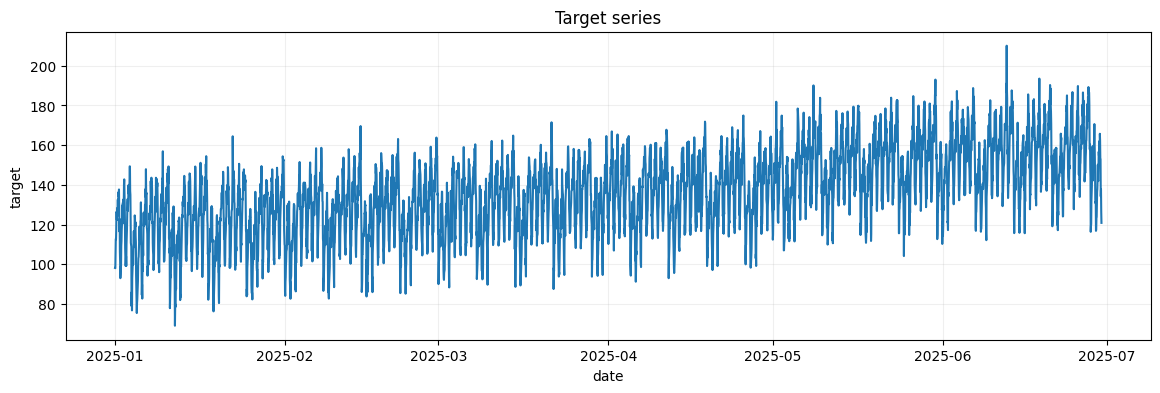

In [3]:

plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['target'])
plt.title('Target series')
plt.xlabel('date')
plt.ylabel('target')
plt.grid(True, alpha=0.2)
save_fig('series_overview.png')
plt.show()


In [4]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print('train:', len(train_df), train_df['date'].min(), train_df['date'].max())
print('val  :', len(val_df), val_df['date'].min(), val_df['date'].max())
print('test :', len(test_df), test_df['date'].min(), test_df['date'].max())

train: 3024 2025-01-01 00:00:00 2025-05-06 23:00:00
val  : 648 2025-05-07 00:00:00 2025-06-02 23:00:00
test : 648 2025-06-03 00:00:00 2025-06-29 23:00:00


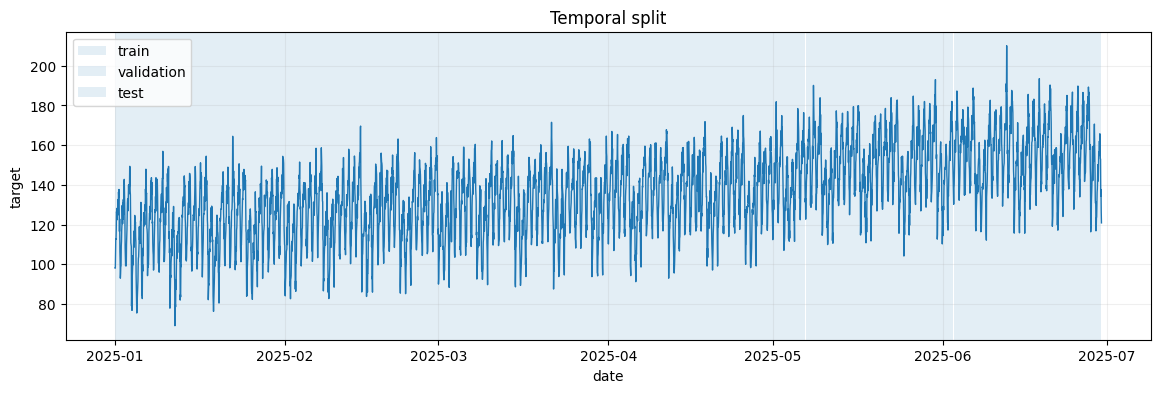

In [5]:

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['target'], linewidth=1)

ax.axvspan(train_df['date'].min(), train_df['date'].max(), alpha=0.12, label='train')
ax.axvspan(val_df['date'].min(), val_df['date'].max(), alpha=0.12, label='validation')
ax.axvspan(test_df['date'].min(), test_df['date'].max(), alpha=0.12, label='test')

ax.set_title('Temporal split')
ax.set_xlabel('date')
ax.set_ylabel('target')
ax.grid(True, alpha=0.2)
ax.legend()
save_fig('series_split.png')
plt.show()


In [6]:
def add_time_features(frame):
    x = frame.copy()
    x['lag_1'] = x['target'].shift(1)
    x['lag_7'] = x['target'].shift(7)
    x['lag_14'] = x['target'].shift(14)
    x['rolling_mean_7'] = x['target'].shift(1).rolling(7).mean()
    x['rolling_std_7'] = x['target'].shift(1).rolling(7).std()
    x['dow'] = x['date'].dt.dayofweek
    x['hour'] = x['date'].dt.hour
    x['month'] = x['date'].dt.month
    x['is_weekend'] = (x['dow'] >= 5).astype(int)
    x['dow_sin'] = np.sin(2 * np.pi * x['dow'] / 7)
    x['dow_cos'] = np.cos(2 * np.pi * x['dow'] / 7)
    x['hour_sin'] = np.sin(2 * np.pi * x['hour'] / 24)
    x['hour_cos'] = np.cos(2 * np.pi * x['hour'] / 24)
    x['month_sin'] = np.sin(2 * np.pi * (x['month'] - 1) / 12)
    x['month_cos'] = np.cos(2 * np.pi * (x['month'] - 1) / 12)
    return x

feat_df = add_time_features(df)
feat_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
             'dow', 'hour', 'month', 'is_weekend',
             'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

In [7]:
# B1: naive-last
val_b1 = val_df['target'].shift(1).copy()
val_b1.iloc[0] = train_df['target'].iloc[-1]
test_b1 = test_df['target'].shift(1).copy()
test_b1.iloc[0] = val_df['target'].iloc[-1]

# Сбросить индексы для корректного сравнения
val_b1 = val_b1.reset_index(drop=True)
test_b1 = test_b1.reset_index(drop=True)

In [8]:
# B2: moving-average
def recursive_moving_average_forecast(full_target, start_idx, end_idx, window=7):
    observed = list(full_target.iloc[:start_idx].values)
    preds = []
    for i in range(start_idx, end_idx):
        preds.append(float(np.mean(observed[-window:])))
        observed.append(float(full_target.iloc[i]))
    return pd.Series(preds, index=full_target.index[start_idx:end_idx])

val_b2 = recursive_moving_average_forecast(df['target'], train_end, val_end, window=7)
test_b2 = recursive_moving_average_forecast(df['target'], val_end, n, window=7)

In [9]:
# B3: Ridge on lag/rolling/calendar features
train_feat = feat_df.iloc[:train_end].copy()
val_feat = feat_df.iloc[train_end:val_end].copy()
test_feat = feat_df.iloc[val_end:].copy()

train_mask = train_feat[feat_cols].notna().all(axis=1)
X_train = train_feat.loc[train_mask, feat_cols]
y_train = train_feat.loc[train_mask, 'target']

scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_val_s = scaler_X.transform(val_feat[feat_cols])
X_test_s = scaler_X.transform(test_feat[feat_cols])

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)

pred_val = ridge.predict(X_val_s)
pred_test = ridge.predict(X_test_s)

In [10]:
class WindowDataset(Dataset):
    def __init__(self, series_scaled, indices, window_size):
        self.series = np.asarray(series_scaled, dtype=np.float32)
        self.indices = np.array(list(indices), dtype=np.int64)
        self.window_size = int(window_size)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        target_idx = int(self.indices[idx])
        x = self.series[target_idx-self.window_size:target_idx]
        y = self.series[target_idx]
        return torch.from_numpy(x).unsqueeze(-1), torch.tensor(y, dtype=torch.float32)

class GRUForecast(nn.Module):
    def __init__(self, hidden_size=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(1, hidden_size, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)

In [11]:
# R1 training and evaluation are implemented in the final cell below.
print('GRU pipeline will run in the final training cell (with best-by-val checkpoint).')


GRU pipeline will run in the final training cell (with best-by-val checkpoint).


## Artifacts

- `./artifacts/runs.csv`
- `./artifacts/ridge_model.pkl`
- `./artifacts/ridge_scaler.pkl`
- `./artifacts/ridge_config.json`
- `./artifacts/best_gru.pt`
- `./artifacts/best_gru_config.json`
- `./artifacts/figures/series_overview.png`
- `./artifacts/figures/series_split.png`
- `./artifacts/figures/baselines_compare.png`
- `./artifacts/figures/gru_learning_curves.png`
- `./artifacts/figures/best_forecast_test.png`


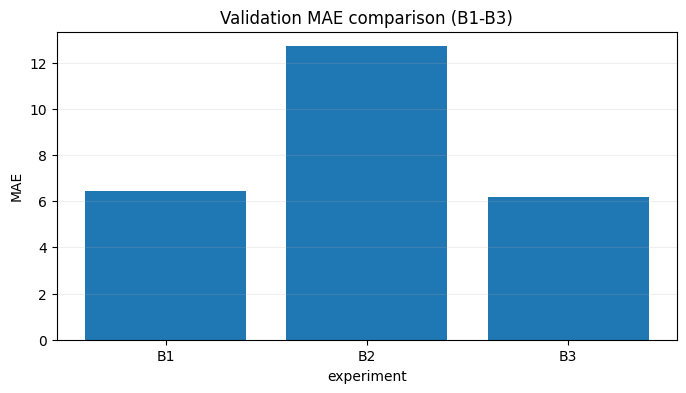

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,"train=3024, val=648, test=648",NaN,1,naive-last,last observed target,none,None,None,0,6.444815,8.201023,4.397922,None,None,None,baseline naive prediction
1,B2,forecasting,S12-hw-dataset.csv,42,"train=3024, val=648, test=648",7.0,1,moving-average,rolling mean of target,none,None,None,0,12.702013,15.217645,8.816864,None,None,None,recursive moving average baseline
2,B3,forecasting,S12-hw-dataset.csv,42,"train=3024, val=648, test=648",NaN,1,Ridge,"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler,None,None,0,6.170800,7.483633,4.093544,None,None,None,"lag, rolling, calendar features"


In [12]:
# Evaluate baselines on validation only (test will be used once after global selection)
y_val = val_df['target'].reset_index(drop=True)
y_test = test_df['target'].reset_index(drop=True)

val_b1 = val_b1.reset_index(drop=True)
test_b1 = test_b1.reset_index(drop=True)
val_b2 = val_b2.reset_index(drop=True)
test_b2 = test_b2.reset_index(drop=True)
pred_val_s = pd.Series(pred_val).reset_index(drop=True)
pred_test_s = pd.Series(pred_test).reset_index(drop=True)

baseline_rows = [
    {
        'experiment_id': 'B1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': SEED,
        'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'naive-last',
        'features_summary': 'last observed target',
        'scaler': 'none',
        'optimizer': None,
        'lr': None,
        'epochs_trained': 0,
        'best_val_mae': mae(y_val, val_b1),
        'best_val_rmse': rmse(y_val, val_b1),
        'best_val_mape': mape(y_val, val_b1),
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': 'baseline naive prediction',
    },
    {
        'experiment_id': 'B2',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': SEED,
        'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
        'window_size': 7,
        'horizon': 1,
        'model_summary': 'moving-average',
        'features_summary': 'rolling mean of target',
        'scaler': 'none',
        'optimizer': None,
        'lr': None,
        'epochs_trained': 0,
        'best_val_mae': mae(y_val, val_b2),
        'best_val_rmse': rmse(y_val, val_b2),
        'best_val_mape': mape(y_val, val_b2),
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': 'recursive moving average baseline',
    },
    {
        'experiment_id': 'B3',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': SEED,
        'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'Ridge',
        'features_summary': ', '.join(feat_cols),
        'scaler': 'StandardScaler',
        'optimizer': None,
        'lr': None,
        'epochs_trained': 0,
        'best_val_mae': mae(y_val, pred_val_s),
        'best_val_rmse': rmse(y_val, pred_val_s),
        'best_val_mape': mape(y_val, pred_val_s),
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': 'lag, rolling, calendar features',
    },
]

baseline_df = pd.DataFrame(baseline_rows)

# Save ridge artifacts
joblib.dump(ridge, ARTIFACT_DIR / 'ridge_model.pkl')
joblib.dump(scaler_X, ARTIFACT_DIR / 'ridge_scaler.pkl')
save_json({
    'model': 'Ridge',
    'alpha': 1.0,
    'seed': SEED,
    'features': feat_cols,
    'dataset': 'S12-hw-dataset.csv',
    'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
}, 'ridge_config.json')

# Comparison plot (validation only)
plt.figure(figsize=(8, 4))
plt.bar(baseline_df['experiment_id'], baseline_df['best_val_mae'])
plt.title('Validation MAE comparison (B1-B3)')
plt.xlabel('experiment')
plt.ylabel('MAE')
plt.grid(axis='y', alpha=0.2)
save_fig('baselines_compare.png')
plt.show()

display(baseline_df)


<!-- GRU artifacts saved in training cell -->

Epoch 1/10, Val Loss: 0.2658, Val MAE: 7.6523
Epoch 2/10, Val Loss: 0.2096, Val MAE: 6.8247
Epoch 3/10, Val Loss: 0.2418, Val MAE: 7.3725
Epoch 4/10, Val Loss: 0.2108, Val MAE: 6.9025
Epoch 5/10, Val Loss: 0.1924, Val MAE: 6.5984
Epoch 6/10, Val Loss: 0.2161, Val MAE: 7.0048
Epoch 7/10, Val Loss: 0.1760, Val MAE: 6.1314
Epoch 8/10, Val Loss: 0.1652, Val MAE: 5.9102
Epoch 9/10, Val Loss: 0.1503, Val MAE: 5.6633
Epoch 10/10, Val Loss: 0.1548, Val MAE: 5.7294


/tmp/ipykernel_12611/4194226291.py:118: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  runs_df = pd.concat([baseline_df, pd.DataFrame([r1_row])], ignore_index=True)


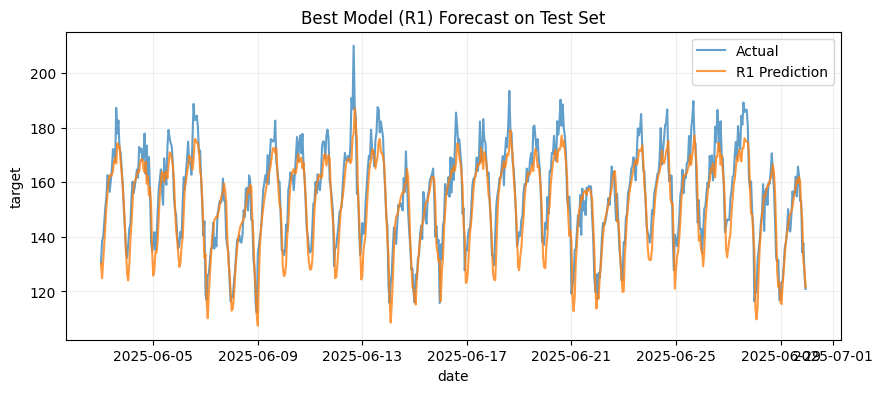

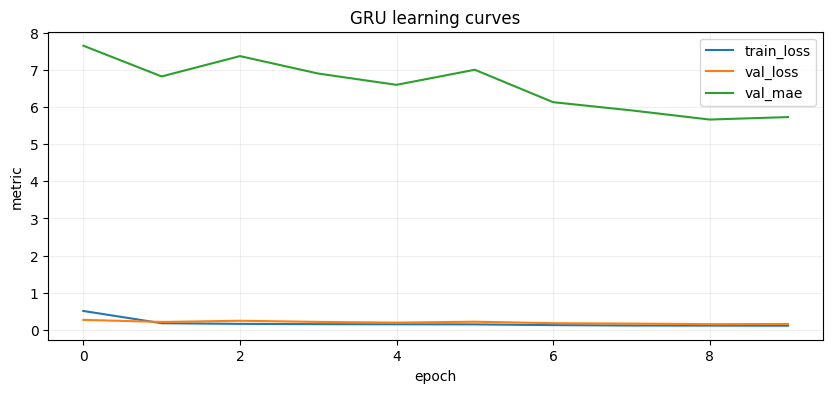

Global best by val_MAE: R1


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,"train=3024, val=648, test=648",NaN,1,naive-last,last observed target,none,None,NaN,0,6.444815,8.201023,4.397922,None,None,None,baseline naive prediction
1,B2,forecasting,S12-hw-dataset.csv,42,"train=3024, val=648, test=648",7.0,1,moving-average,rolling mean of target,none,None,NaN,0,12.702013,15.217645,8.816864,None,None,None,recursive moving average baseline
2,B3,forecasting,S12-hw-dataset.csv,42,"train=3024, val=648, test=648",NaN,1,Ridge,"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler,None,NaN,0,6.170800,7.483633,4.093544,None,None,None,"lag, rolling, calendar features"
3,R1,forecasting,S12-hw-dataset.csv,42,"train=3024, val=648, test=648",24.0,1,gru-forecast,target windows only,StandardScaler,Adam,0.001,9,5.663268,7.203164,3.832673,6.195721,7.88575,4.021039,best checkpoint by val_MAE


In [13]:
WINDOW_SIZE = 24
BATCH_SIZE = 32

# Scaling target (fit only on train)
scaler_y = StandardScaler()
train_scaled = scaler_y.fit_transform(train_df[['target']]).flatten()
val_scaled = scaler_y.transform(val_df[['target']]).flatten()
test_scaled = scaler_y.transform(test_df[['target']]).flatten()
full_series = np.concatenate([train_scaled, val_scaled, test_scaled])

train_len = len(train_scaled)
val_len = len(val_scaled)
test_len = len(test_scaled)

# Train and validation indices for one-step forecast
train_idx = np.arange(WINDOW_SIZE, train_len)
val_idx = np.arange(train_len, train_len + val_len)

train_ds = WindowDataset(full_series, train_idx, WINDOW_SIZE)
val_ds = WindowDataset(full_series, val_idx, WINDOW_SIZE)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# Model
gru = GRUForecast(hidden_size=64).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru.parameters(), lr=0.001)

# Training with best-by-validation checkpoint
history = {'loss': [], 'val_loss': [], 'val_mae': []}
epochs = 10
best_state = None
best_epoch = -1
best_val_mae_gru = float('inf')

for epoch in range(epochs):
    gru.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = gru(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    gru.eval()
    val_loss = 0.0
    val_preds_scaled = []
    with torch.no_grad():
        for x_v, y_v in val_loader:
            x_v, y_v = x_v.to(device), y_v.to(device)
            v_preds = gru(x_v)
            val_loss += criterion(v_preds, y_v).item()
            val_preds_scaled.append(v_preds.cpu().numpy())

    val_preds_scaled = np.concatenate(val_preds_scaled)
    val_preds = scaler_y.inverse_transform(val_preds_scaled.reshape(-1, 1)).flatten()
    y_val_true = val_df['target'].values
    val_mae = mae(y_val_true, val_preds)

    history['loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss / len(val_loader))
    history['val_mae'].append(val_mae)

    if val_mae < best_val_mae_gru:
        best_val_mae_gru = val_mae
        best_epoch = epoch + 1
        best_state = {k: v.detach().cpu().clone() for k, v in gru.state_dict().items()}

    print(f'Epoch {epoch+1}/{epochs}, Val Loss: {val_loss/len(val_loader):.4f}, Val MAE: {val_mae:.4f}')

# Load best checkpoint
best_gru = GRUForecast(hidden_size=64).to(device)
best_gru.load_state_dict(best_state)
best_gru.eval()

def predict_gru_on_indices(model, full_series_scaled, target_indices, window_size, batch_size=64):
    ds = WindowDataset(full_series_scaled, target_indices, window_size)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds_scaled = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            p = model(xb).cpu().numpy()
            preds_scaled.append(p)
    preds_scaled = np.concatenate(preds_scaled)
    preds = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    return preds

# GRU metrics on validation
val_preds_gru = predict_gru_on_indices(best_gru, full_series, val_idx, WINDOW_SIZE)
r1_row = {
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset.csv',
    'seed': SEED,
    'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
    'window_size': WINDOW_SIZE,
    'horizon': 1,
    'model_summary': 'gru-forecast',
    'features_summary': 'target windows only',
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': 0.001,
    'epochs_trained': best_epoch,
    'best_val_mae': mae(val_df['target'].values, val_preds_gru),
    'best_val_rmse': rmse(val_df['target'].values, val_preds_gru),
    'best_val_mape': mape(val_df['target'].values, val_preds_gru),
    'test_mae': None,
    'test_rmse': None,
    'test_mape': None,
    'notes': 'best checkpoint by val_MAE',
}

# Combine B1/B2/B3 with R1 and select global best by validation MAE
runs_df = pd.concat([baseline_df, pd.DataFrame([r1_row])], ignore_index=True)
best_exp = runs_df.loc[runs_df['best_val_mae'].idxmin(), 'experiment_id']

# Use test exactly once for the global best model
if best_exp == 'B1':
    best_test_pred = test_b1.values
elif best_exp == 'B2':
    best_test_pred = test_b2.values
elif best_exp == 'B3':
    best_test_pred = pred_test_s.values
else:
    test_idx = np.arange(train_len + val_len, train_len + val_len + test_len)
    best_test_pred = predict_gru_on_indices(best_gru, full_series, test_idx, WINDOW_SIZE)

best_mask = runs_df['experiment_id'] == best_exp
runs_df.loc[best_mask, 'test_mae'] = mae(test_df['target'].values, best_test_pred)
runs_df.loc[best_mask, 'test_rmse'] = rmse(test_df['target'].values, best_test_pred)
runs_df.loc[best_mask, 'test_mape'] = mape(test_df['target'].values, best_test_pred)

# Save final runs.csv (contains B1, B2, B3, R1)
save_df(runs_df, 'runs.csv')

# Plot best forecast on test
plt.figure(figsize=(10, 4))
plt.plot(test_df['date'], test_df['target'].values, label='Actual', alpha=0.7)
plt.plot(test_df['date'], best_test_pred, label=f'{best_exp} Prediction', alpha=0.8)
plt.title(f'Best Model ({best_exp}) Forecast on Test Set')
plt.xlabel('date')
plt.ylabel('target')
plt.legend()
plt.grid(True, alpha=0.2)
save_fig('best_forecast_test.png')
plt.show()

gru_config = {
    'model': 'GRU',
    'hidden_size': 64,
    'window_size': WINDOW_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': 0.001,
    'epochs': epochs,
    'best_epoch_by_val_mae': best_epoch,
    'seed': SEED,
    'scaler': 'StandardScaler',
    'scaler_fit_on': 'train_only',
    'optimizer': 'Adam',
    'dataset': 'S12-hw-dataset.csv',
    'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
}

# Save GRU artifacts
torch.save(best_gru.state_dict(), ARTIFACT_DIR / 'best_gru.pt')
history_df = pd.DataFrame(history)
history_df.to_csv(ARTIFACT_DIR / 'gru_history.csv', index=False)

plt.figure(figsize=(10, 4))
plt.plot(history_df['loss'], label='train_loss')
plt.plot(history_df['val_loss'], label='val_loss')
plt.plot(history_df['val_mae'], label='val_mae')
plt.title('GRU learning curves')
plt.xlabel('epoch')
plt.ylabel('metric')
plt.grid(True, alpha=0.2)
plt.legend()
save_fig('gru_learning_curves.png')
plt.show()

save_json(gru_config, 'best_gru_config.json')

print(f'Global best by val_MAE: {best_exp}')
display(runs_df)
